In [1]:
import os
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision.utils import make_grid
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [3]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR = os.path.join(ROOT_DIR, 'data')
print(os.listdir(DATA_DIR))
classes = os.listdir(os.path.join(DATA_DIR, 'train'))
print(classes)

['train', 'valid']
['h_blur', 'low_light', 'low_qual', 'normal', 'v_blur']


### Data Transformation

In [5]:
# Data transforms (normalization & data augmentation)
stats = ((0.46788563, 0.47724397, 0.48490899), (0.23993908, 0.2449926, 0.23935836))
train_tfms = T.Compose([T.Resize([256, 128]),
                        T.RandomPerspective(distortion_scale=0.5, p=0.5), 
                        T.ColorJitter(hue=.3),
                        T.ToTensor(),
                        T.Normalize(*stats, inplace=True)])
valid_tfms = T.Compose([T.Resize([256, 128]), T.ToTensor(), T.Normalize(*stats)])

### PyTorch Datasets / Data Loaders

In [8]:
train_ds = ImageFolder(os.path.join(DATA_DIR, 'train'), train_tfms)
valid_ds = ImageFolder(os.path.join(DATA_DIR, 'valid'), valid_tfms)

In [80]:
batch_size = 64

In [82]:
# PyTorch Data Loaders
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size*2, num_workers=3, pin_memory=True)

In [84]:
def denormalize(images, means, stds):
    means = torch.tensor(means).reshape(1, 3, 1, 1)
    stds = torch.tensor(stds).reshape(1, 3, 1, 1)
    return images * stds + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        denorm_images = denormalize(images, *stats)
        ax.imshow(make_grid(denorm_images[:32], nrow=8).permute(1, 2, 0).clamp(0, 1))
        break

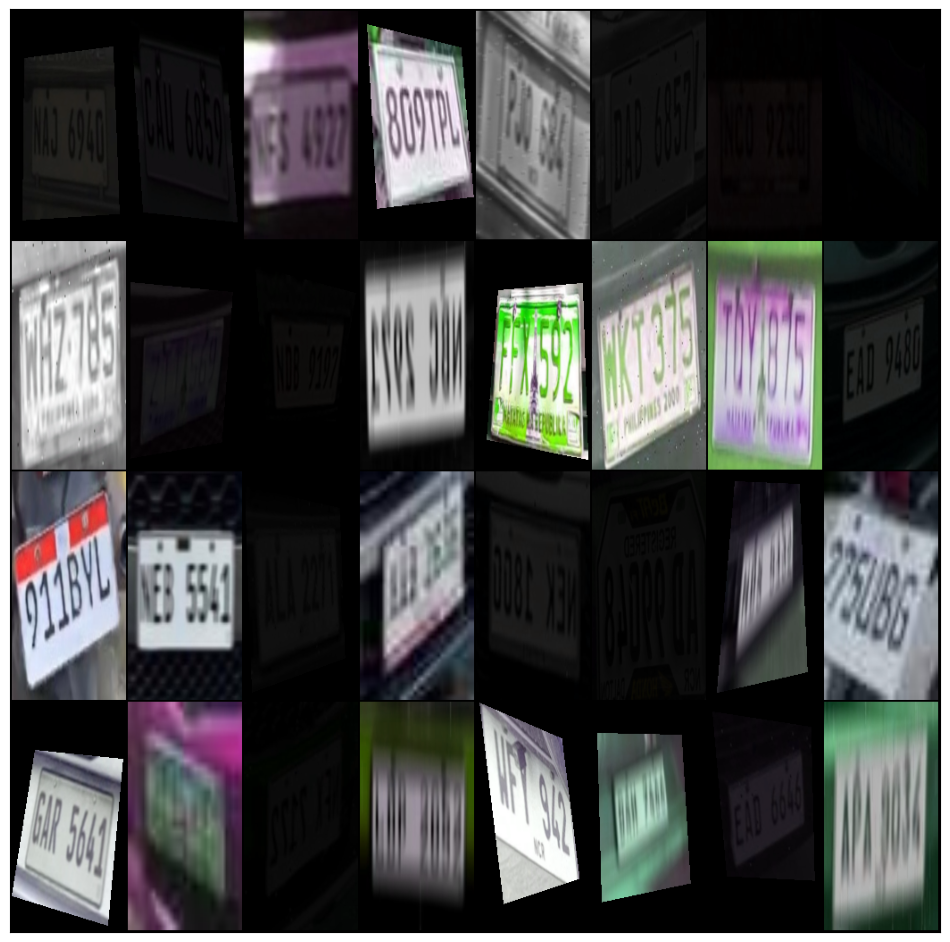

In [85]:
show_batch(train_dl)

### Using GPU

In [86]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

In [88]:
device = get_default_device()
device

device(type='cuda')

In [90]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

### Model Development

In [93]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()        # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()           # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print(f'Epoch [{epoch}], last_lr: {result['lrs'][-1]:.5f}, train_loss: {result['train_loss']:.4f},' + 
              f'val_loss: {result['val_loss']:.4f}, val_acc: {result['val_acc']:.4f}')

In [95]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channels),
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet18(ImageClassificationBase):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        # 3 x 256 x 128
        self.conv1 = conv_block(in_channels, 64, pool=True) # 64 x 128 x 64
        self.conv2 = conv_block(64, 128, pool=True) # 128 x 64 x 32
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128)) # 128 x 64 x 32

        self.conv3 = conv_block(128, 256, pool=True) # 256 x 32 x 16
        self.conv4 = conv_block(256, 512, pool=True) # 512 x 16 x 8
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512)) # 512 x 16 x 8

        self.classifier = nn.Sequential(nn.MaxPool2d(2), # 512 x 8 x 4
                                        nn.Flatten(),
                                        nn.Dropout(0.2),
                                        nn.Linear(512 * 8 * 4, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

In [97]:
model = to_device(ResNet18(3, 10), device)
model

ResNet18(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1

In [99]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0, grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []

    # Set up custom optimizer with weight decay
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # Set up one-cycle learning rate scheduling
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, 
                                                steps_per_epoch=len(train_loader))

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_losses = []
        lrs = []
        for batch in tqdm(train_loader):
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()

            # Gradient clipping
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            # Record and update learning rate
            lrs.append(get_lr(optimizer))
            sched.step()

        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [54]:
history = [evaluate(model, valid_dl)]
history

[{'val_loss': 2.304058790206909, 'val_acc': 0.1938100904226303}]

In [101]:
history = []
epochs = 20
max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.Adam

In [103]:
%%time
history += fit_one_cycle(epochs, max_lr, model, train_dl, valid_dl,
                         grad_clip=grad_clip,
                         weight_decay=weight_decay,
                         opt_func=opt_func)

100%|████████████████████████████████████████████████████████████████████████████████| 929/929 [03:20<00:00,  4.64it/s]


Epoch [0], last_lr: 0.00104, train_loss: 0.7791,val_loss: 0.2826, val_acc: 0.9298


100%|████████████████████████████████████████████████████████████████████████████████| 929/929 [03:25<00:00,  4.52it/s]


Epoch [1], last_lr: 0.00280, train_loss: 0.4471,val_loss: 0.2660, val_acc: 0.9074


100%|████████████████████████████████████████████████████████████████████████████████| 929/929 [03:34<00:00,  4.33it/s]


...

Epoch [17], last_lr: 0.00050, train_loss: 0.0342,val_loss: 0.0200, val_acc: 0.9950


100%|████████████████████████████████████████████████████████████████████████████████| 929/929 [03:25<00:00,  4.52it/s]


Epoch [18], last_lr: 0.00013, train_loss: 0.0289,val_loss: 0.0169, val_acc: 0.9961


100%|████████████████████████████████████████████████████████████████████████████████| 929/929 [03:26<00:00,  4.51it/s]


Epoch [19], last_lr: 0.00000, train_loss: 0.0269,val_loss: 0.0168, val_acc: 0.9964
CPU times: total: 8min 9s
Wall time: 1h 12min 46s


In [78]:
torch.cuda.empty_cache()

In [ ]:
torch.save(model.state_dict(), "model_weights.pt")